**Autores:**

- Gonçalo Henriques (123422)
- Rodrigo Sousa (123390)

In [1]:
# Importações básicas
import pyspark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql.functions import when
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
from pymongo import MongoClient
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2
import json, os

In [2]:
# Spark Session otimizada para máquinas locais com CPU híbrido (P‑cores + E‑cores) e 16 GB RAM.
# Configuração ajustada para maximizar paralelismo, evitar swap e acelerar operações com ~35M linhas.

spark = (
    SparkSession.builder
        .appName("LondonBikesDataUnderstanding")  
        # Nome da aplicação — aparece no Spark UI e logs.

        .master("local[20]")  
        # Define o número de logical processors usados (20 threads = 6 P‑cores*2 + 8 E‑cores*1).
        # Garante paralelismo máximo sem sobrecarregar o sistema.

        .config("spark.driver.memory", "10g")  
        # Memória atribuída ao driver (processo principal). 
        # 10 GB é o valor ideal para uma máquina com 16 GB sem provocar swap.

        .config("spark.executor.memory", "10g")  
        # Memória para os executors (as threads que executam tarefas).
        # Mantém o mesmo valor do driver para consistência e estabilidade.

        .config("spark.sql.shuffle.partitions", "40")  
        # Número de partições usadas em operações com shuffle (groupBy, join, orderBy).
        # Regra prática: ~2× número de cores → reduz tempo de shuffle e melhora throughput.

        .config("spark.default.parallelism", "40")  
        # Paralelismo padrão para RDDs e algumas operações internas.
        # Mantém alinhado com o número de partições para evitar gargalos.

        .getOrCreate()
)

spark

In [3]:
# Ligar ao MongoDB (o nome do serviço resolve-se dentro da rede Docker Compose)
client = MongoClient("mongodb://mongodb:27017/")
db = client["london_bikes"]
client.admin.command("ping")
client

MongoClient(host=['mongodb:27017'], document_class=dict, tz_aware=False, connect=True)

---
# **2 - Compreensão e Preparação dos Dados**

Este notebook realiza análise exploratória e limpeza de dados sobre o dataset London Bikes.

O ficheiro Parquet é lido a partir de `data/london-bicycle/`, gerado pelo `1-DataIngestion.ipynb`.

**Passos de limpeza aplicados:**
1. Identificar e remover registos onde `docks = 0`
2. Identificar e remover registos inconsistentes onde `bikes + empty_docks ≠ docks`
3. Corrigir ou remover registos com coordenadas inválidas (`lat = 0` e `lon = 0`)
4. Uniformizar coordenadas para BikePoints com múltiplas localizações registadas
5. Dividir o dataset limpo por estação do ano e guardar cada subconjunto como Parquet
6. Escrever o dataset limpo completo no MongoDB

**NOTA**: Este notebook deve ser executado de forma estritamente sequencial para garantir resultados corretos.

---
## **1. Carregar Dados**

In [4]:
# Leitura do dataset Parquet produzido pelo notebook de ingestão
df = spark.read.parquet('data/london-bicycle')

In [5]:
# Visão geral inicial do dataset
print(f'Total de linhas: {df.count()}')
df.printSchema()
df.show(10, truncate=False)

Total de linhas: 35049957
root
 |-- query_time: timestamp (nullable = true)
 |-- place_id: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- bikes: integer (nullable = true)
 |-- empty_docks: integer (nullable = true)
 |-- docks: integer (nullable = true)

+--------------------------+-------------+---------+---------+-----+-----------+-----+
|query_time                |place_id     |lat      |lon      |bikes|empty_docks|docks|
+--------------------------+-------------+---------+---------+-----+-----------+-----+
|2023-02-26 00:19:17.356648|BikePoints_1 |51.529163|-0.10997 |5    |14         |19   |
|2023-02-26 00:19:17.356648|BikePoints_2 |51.499606|-0.197574|10   |27         |37   |
|2023-02-26 00:19:17.356648|BikePoints_3 |51.521283|-0.084605|12   |20         |32   |
|2023-02-26 00:19:17.356648|BikePoints_4 |51.530059|-0.120973|17   |6          |23   |
|2023-02-26 00:19:17.356648|BikePoints_5 |51.49313 |-0.156876|16   |11         |27  

O dataset é uma **série temporal**: os registos não são gerados a intervalos fixos.
Uma atualização é despoletada sempre que qualquer BikePoint muda de estado, pelo que
o intervalo entre observações é irregular e varia entre estações.

In [6]:
# Ilustração do intervalo irregular de atualização para um único BikePoint
df.filter(df['place_id'] == 'BikePoints_8').show(10, truncate=False)

+--------------------------+------------+---------+---------+-----+-----------+-----+
|query_time                |place_id    |lat      |lon      |bikes|empty_docks|docks|
+--------------------------+------------+---------+---------+-----+-----------+-----+
|2023-02-26 00:19:17.356648|BikePoints_8|51.529857|-0.183486|9    |30         |39   |
|2023-02-26 00:36:52.428974|BikePoints_8|51.529857|-0.183486|9    |30         |39   |
|2023-02-26 01:14:50.900182|BikePoints_8|51.529857|-0.183486|10   |29         |39   |
|2023-02-26 01:56:59.986974|BikePoints_8|51.529857|-0.183486|10   |29         |39   |
|2023-02-26 02:35:36.97935 |BikePoints_8|51.529857|-0.183486|10   |29         |39   |
|2023-02-26 03:07:39.78349 |BikePoints_8|51.529857|-0.183486|11   |28         |39   |
|2023-02-26 03:28:36.231929|BikePoints_8|51.529857|-0.183486|11   |28         |39   |
|2023-02-26 03:42:06.189422|BikePoints_8|51.529857|-0.183486|11   |28         |39   |
|2023-02-26 03:52:35.651649|BikePoints_8|51.529857|-0.

---
## **2. Estatísticas Descritivas**

In [7]:
df.describe().show()

+-------+-------------+-------------------+--------------------+------------------+-----------------+-----------------+
|summary|     place_id|                lat|                 lon|             bikes|      empty_docks|            docks|
+-------+-------------+-------------------+--------------------+------------------+-----------------+-----------------+
|  count|     35049957|           35049957|            35049957|          35049957|         35049957|         35049957|
|   mean|         NULL|  51.50493339769663|-0.12727754386892884|12.385030286913048|13.81485141336978|26.43779802639986|
| stddev|         NULL|0.22660073105754897| 0.05498382285113037| 9.293543909698487|9.785066817444493|8.840859972377896|
|    min| BikePoints_1|                0.0|           -0.236769|                 0|                0|                0|
|    max|BikePoints_99|          51.549369|                 0.0|                64|               64|               64|
+-------+-------------+-----------------

**Observações das estatísticas descritivas:**
- `lat` e `lon` têm um mínimo de `0.0`, o que é geograficamente impossível para Londres — são erros nos dados;
- `docks` tem um mínimo de `0`, indicando registos em que uma estação não tinha docas registadas;
- `bikes` e `empty_docks` têm ambos um máximo de `64`, igual ao valor máximo de `docks` — consistente.

In [8]:
# Verificação de unicidade: quantos BikePoints distintos existem no dataset em bruto?
bikepoints_raw = df.select('place_id').distinct().count()
print(f'BikePoints distintos no dataset em bruto: {bikepoints_raw}')

BikePoints distintos no dataset em bruto: 813


In [9]:
# Verificar valores nulos em todas as colunas
print('Contagem de nulos por coluna:')
null_counts = {col: df.filter(df[col].isNull()).count() for col in df.columns}
null_counts

Contagem de nulos por coluna:


{'query_time': 0,
 'place_id': 0,
 'lat': 0,
 'lon': 0,
 'bikes': 0,
 'empty_docks': 0,
 'docks': 0}

Não existem valores nulos no dataset. Os problemas de qualidade dos dados estão codificados como
**valores numéricos inválidos** (ex: `0` para coordenadas, `0` para docas) em vez de nulos.

---
## **3. Limpeza de Dados**

### **3.1 Remover registos onde `docks = 0`**

Uma estação com zero docas não pode existir fisicamente. Estes registos correspondem
provavelmente a estações em processo de instalação ou desativação.

In [10]:
total_rows = df.count()

null_docks_count = df.filter(df['docks'] == 0).count()
print(f'Registos onde docks = 0: {null_docks_count}')

df = df.filter(df['docks'] != 0)
total_rows_without_zero_docks = df.count()
print(f'Linhas removidas: {total_rows - total_rows_without_zero_docks}')
print(f'Linhas restantes: {total_rows_without_zero_docks}')

Registos onde docks = 0: 32890
Linhas removidas: 32890
Linhas restantes: 35017067


### **3.2 Remover registos inconsistentes (`bikes + empty_docks ≠ docks`)**

Por definição (https://api-portal.tfl.gov.uk/api-details#api=BikePoint&operation=BikePoint_GetAll), `bikes + empty_docks` deve ser igual a `docks`.
Registos que violam esta condição são provavelmente causados por erros de sensores ou
snapshots capturados a meio de uma atualização, e são removidos.

In [11]:
inconsistent_count = df.filter(df['bikes'] + df['empty_docks'] != df['docks']).count()
print(f'Registos inconsistentes (bikes + empty_docks ≠ docks): {inconsistent_count}')

df = df.filter(df['bikes'] + df['empty_docks'] == df['docks'])
total_rows_valid_docks = df.count()
print(f'Linhas removidas: {total_rows_without_zero_docks - total_rows_valid_docks}')
print(f'Linhas restantes: {total_rows_valid_docks}')

Registos inconsistentes (bikes + empty_docks ≠ docks): 5003965
Linhas removidas: 5003965
Linhas restantes: 30013102


### **3.3 Corrigir coordenadas inválidas (`lat = 0` e `lon = 0`)**

Três BikePoints têm registos em que tanto `lat` como `lon` são `0.0`.
Isto corresponde à **Ilha Nula** (interseção do meridiano de Greenwich com o equador),
o que é claramente erróneo para uma rede de bicicletas em Londres.

Estratégia:
- **BikePoints_852**: tem coordenadas válidas noutros registos → corrigir as entradas com valor zero usando a localização conhecida da `API TFL`.
- **BikePoints_853 e BikePoints_856**: os registos com coordenadas válidas são mantidos, mas os registos com zero são removidos porque estas estações não existem na `API TFL`.

In [12]:
# Identificar BikePoints que têm registos com coordenadas iguais a zero
df.filter((df['lat'] == 0.0) & (df['lon'] == 0.0)) \
  .select('place_id').distinct().show()

+--------------+
|      place_id|
+--------------+
|BikePoints_853|
|BikePoints_852|
|BikePoints_856|
+--------------+



In [13]:
# Mostrar todos os pares de coordenadas distintos para esses três BikePoints
# para confirmar quais têm coordenadas válidas noutros registos
bike_points_zero = ['BikePoints_852', 'BikePoints_853', 'BikePoints_856']

df_filtered_ZeroLoc = (
    df.filter(df['place_id'].isin(bike_points_zero))
      .select('place_id', 'lat', 'lon')
      .distinct()
      .orderBy('place_id')  
)

df_filtered_ZeroLoc.show(truncate=False)

df_filtered_ZeroLoc.groupBy('place_id').count().show()

+--------------+---------+---------+
|place_id      |lat      |lon      |
+--------------+---------+---------+
|BikePoints_852|51.48357 |-0.202038|
|BikePoints_852|0.0      |0.0      |
|BikePoints_853|51.46161 |-0.216145|
|BikePoints_853|0.0      |0.0      |
|BikePoints_856|51.527842|-0.108068|
|BikePoints_856|0.0      |0.0      |
+--------------+---------+---------+

+--------------+-----+
|      place_id|count|
+--------------+-----+
|BikePoints_856|    2|
|BikePoints_853|    2|
|BikePoints_852|    2|
+--------------+-----+



In [14]:
# BikePoints_852: corrigir os registos com coordenadas zero usando a localização válida conhecida.
# BikePoints_853 e BikePoints_856 também têm registos com coordenadas válidas;
# os seus registos com zero serão removidos pelo filtro abaixo.

df = df.withColumn(
    'lat',
    when((df['place_id'] == 'BikePoints_852') & (df['lat'] == 0.0), 51.48357)
    .otherwise(df['lat'])
).withColumn(
    'lon',
    when((df['place_id'] == 'BikePoints_852') & (df['lon'] == 0.0), -0.202038)
    .otherwise(df['lon'])
)

# Remover todos os registos com coordenadas zero restantes
df = df.filter((df['lat'] != 0.0) & (df['lon'] != 0.0))
total_rows_fixed_zero_coords = df.count()
print(f'Linhas removidas (coordenadas zero): {total_rows_valid_docks - total_rows_fixed_zero_coords}')
print(f'Linhas restantes: {total_rows_fixed_zero_coords}')

Linhas removidas (coordenadas zero): 79
Linhas restantes: 30013023


### **3.4 Uniformizar BikePoints com múltiplas localizações registadas**

Após remover os registos com coordenadas zero, alguns BikePoints aparecem ainda com
mais do que um par distinto `(lat, lon)`. Isto indica que as estações foram
fisicamente relocalizadas em algum momento. As coordenadas mais recentes (obtidas da
`API TFL`) são usadas para uniformizar todos os registos dessas estações.

In [15]:
# Encontrar BikePoints que ainda têm mais do que um par de coordenadas distinto
df_dist = df.select('place_id', 'lat', 'lon').distinct()

multi_coord = (
    df_dist.groupBy('place_id')
    .agg(F.count('place_id').alias('coord_count'))
    .filter(F.col('coord_count') >= 2)
)
multi_coord.show()

+--------------+-----------+
|      place_id|coord_count|
+--------------+-----------+
|BikePoints_532|          2|
| BikePoints_14|          2|
|BikePoints_289|          2|
+--------------+-----------+



In [16]:
# Mostrar os pares de coordenadas diferentes para esses BikePoints
multi_ids = [row['place_id'] for row in multi_coord.collect()]

df_filtered_Diff_Loc = (
    df_dist.filter(df_dist['place_id'].isin(multi_ids))
      .orderBy('place_id')  
)

df_filtered_Diff_Loc.show(truncate=False)

+--------------+---------+---------+
|place_id      |lat      |lon      |
+--------------+---------+---------+
|BikePoints_14 |51.529943|-0.123616|
|BikePoints_14 |51.529416|-0.123944|
|BikePoints_289|51.50923 |-0.151289|
|BikePoints_289|51.50923 |-0.151296|
|BikePoints_532|51.5034  |-0.020242|
|BikePoints_532|51.50357 |-0.020068|
+--------------+---------+---------+



In [17]:
# Fórmula de Haversine para calcular a distância entre duas coordenadas geográficas.
# R é o raio médio da Terra em quilómetros.
# O resultado é convertido para metros multiplicando por 1000.

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Raio da Terra em quilómetros
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c * 1000  # Distância em metros

In [18]:
# Deslocamento entre as duas localizações registadas para cada BikePoint afetado
print(f"BikePoints_14:  {haversine(51.529943, -0.123616, 51.529416, -0.123944):.2f} metros")
print(f"BikePoints_289: {haversine(51.50923, -0.151289, 51.50923, -0.151296):.2f} metros")
print(f"BikePoints_532: {haversine(51.5034, -0.020242, 51.50357, -0.020068):.2f} metros")

BikePoints_14:  62.84 metros
BikePoints_289: 0.48 metros
BikePoints_532: 22.41 metros


O deslocamento máximo é de **62,84 metros** (BikePoints_14), o que está dentro da
margem típica de uma relocalização física menor. As coordenadas atuais foram obtidas
da `API TFL` e são usadas para uniformizar todos os registos.

In [19]:
# Uniformizar coordenadas para BikePoints com múltiplas localizações registadas.
# As coordenadas atuais verificadas pela API são aplicadas a todos os registos históricos.

coord_corrections = {
    'BikePoints_532': (51.5034,    -0.020242),
    'BikePoints_289': (51.50923,   -0.151289),
    'BikePoints_14':  (51.529416,  -0.123944),
}

for place_id, (lat, lon) in coord_corrections.items():
    df = df.withColumn(
        'lat',
        when(df['place_id'] == place_id, lat).otherwise(df['lat'])
    ).withColumn(
        'lon',
        when(df['place_id'] == place_id, lon).otherwise(df['lon'])
    )

print('Uniformização de coordenadas aplicada.')

Uniformização de coordenadas aplicada.


---
## **4. Enriquecimento de Variáveis**

Extrair `Date` e `Hour` de `query_time` para suportar análise temporal.

In [20]:
df = (
    df
    .withColumn('Date', F.to_date(F.col('query_time')))
    .withColumn('Hour', F.hour(F.col('query_time')))
    .withColumn('Minute', F.minute(F.col('query_time')))
)

df.show(5)

+--------------------+------------+---------+---------+-----+-----------+-----+----------+----+------+
|          query_time|    place_id|      lat|      lon|bikes|empty_docks|docks|      Date|Hour|Minute|
+--------------------+------------+---------+---------+-----+-----------+-----+----------+----+------+
|2023-02-26 00:19:...|BikePoints_1|51.529163| -0.10997|    5|         14|   19|2023-02-26|   0|    19|
|2023-02-26 00:19:...|BikePoints_2|51.499606|-0.197574|   10|         27|   37|2023-02-26|   0|    19|
|2023-02-26 00:19:...|BikePoints_3|51.521283|-0.084605|   12|         20|   32|2023-02-26|   0|    19|
|2023-02-26 00:19:...|BikePoints_4|51.530059|-0.120973|   17|          6|   23|2023-02-26|   0|    19|
|2023-02-26 00:19:...|BikePoints_5| 51.49313|-0.156876|   16|         11|   27|2023-02-26|   0|    19|
+--------------------+------------+---------+---------+-----+-----------+-----+----------+----+------+
only showing top 5 rows



In [21]:
# Confirmar o intervalo temporal do dataset limpo
min_date = df.agg(F.min('Date')).collect()[0][0]
max_date = df.agg(F.max('Date')).collect()[0][0]
print(f'O dataset abrange de {min_date} a {max_date}')

O dataset abrange de 2022-04-29 a 2023-09-20


---
## **5. Resumo da Limpeza**

In [22]:
total_final = df.count()

print('=== Resumo da Limpeza ===')
print(f'Registos em bruto:                           {total_rows:>12,}')
print(f'Após remover docks = 0:                      {total_rows_without_zero_docks:>12,}  (removidos {total_rows - total_rows_without_zero_docks:,})')
print(f'Após remover linhas inconsistentes:          {total_rows_valid_docks:>12,}  (removidos {total_rows_without_zero_docks - total_rows_valid_docks:,})')
print(f'Após corrigir coordenadas zero:              {total_rows_fixed_zero_coords:>12,}  (removidos {total_rows_valid_docks - total_rows_fixed_zero_coords:,})')
print(f'Dataset limpo final:                         {total_final:>12,}')
print(f'Total de linhas removidas:                   {total_rows - total_final:>12,}  ({(total_rows - total_final)/total_rows*100:.1f}%)')

=== Resumo da Limpeza ===
Registos em bruto:                             35,049,957
Após remover docks = 0:                        35,017,067  (removidos 32,890)
Após remover linhas inconsistentes:            30,013,102  (removidos 5,003,965)
Após corrigir coordenadas zero:                30,013,023  (removidos 79)
Dataset limpo final:                           30,013,023
Total de linhas removidas:                      5,036,934  (14.4%)


---
## **6. Análise Exploratória de Dados**

### **6.1 Distribuição da capacidade de docas por estação**

Utilizando a contagem mais recente de docas por estação para representar a sua capacidade atual.

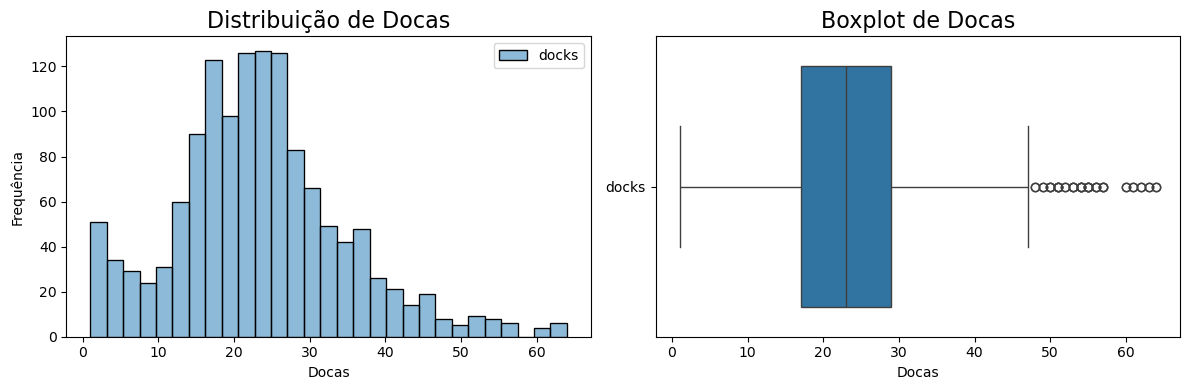

In [23]:
# Contagens distintas de docas observadas por BikePoint
df_dist = df.select('place_id', 'docks').distinct()

dock_capacity_pdf = df_dist.select('docks').toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    dock_capacity_pdf,
    ax=axes[0]
)
axes[0].set_title('Distribuição de Docas', fontsize=16)
axes[0].set_xlabel('Docas')
axes[0].set_ylabel('Frequência')

sns.boxplot(
    dock_capacity_pdf,
    orient='h',
    ax=axes[1]
)
axes[1].set_title('Boxplot de Docas', fontsize=16)
axes[1].set_xlabel('Docas')

plt.tight_layout()
plt.savefig('visualizations/dock_capacity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### **6.2 Análise de Correlação**

Correlação de Pearson entre `bikes`, `empty_docks` e `docks`.
Para o clustering K-means (baseado em distâncias), a multicolinearidade entre as
variáveis de entrada pode distorcer as distâncias entre pontos. Uma correlação moderada é aceitável.

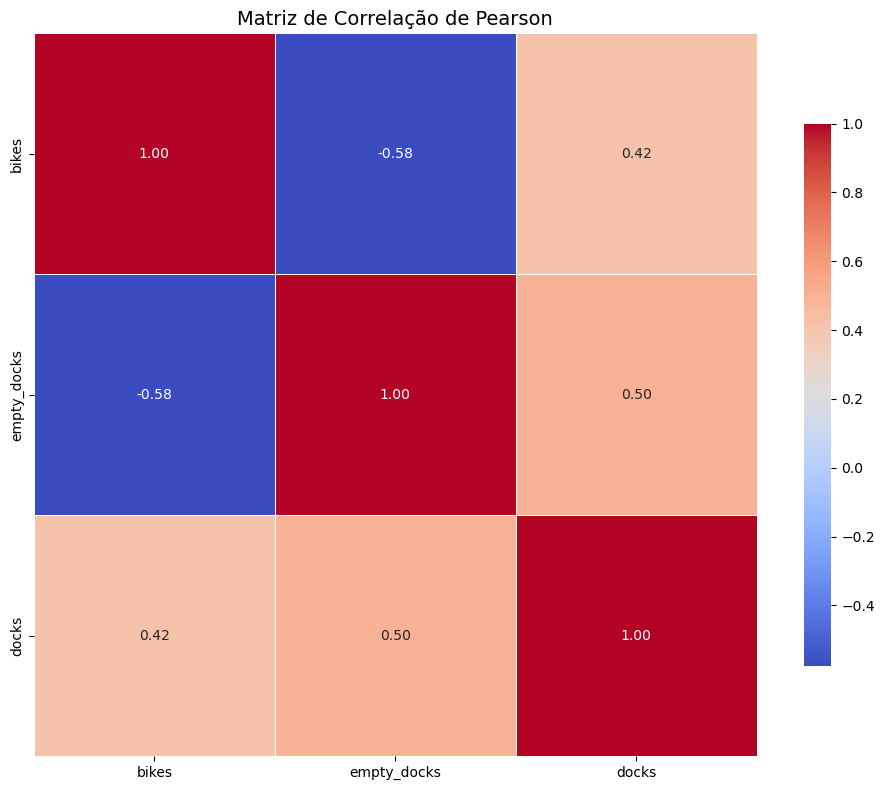

In [24]:
cols_corr = ['bikes', 'empty_docks', 'docks']

assembler = VectorAssembler(inputCols=cols_corr, outputCol='features')
df_vector = assembler.transform(df).select('features')

corr_matrix = Correlation.corr(df_vector, 'features').collect()[0][0].toArray()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    xticklabels=cols_corr,
    yticklabels=cols_corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.75},
    ax=ax
)
ax.set_title('Matriz de Correlação de Pearson', fontsize=14)

plt.tight_layout()
plt.savefig('visualizations/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretação:**
- **`bikes` vs `empty_docks`**: correlação negativa forte — à medida que as bicicletas disponíveis aumentam, as docas vazias diminuem. Esperado pela construção (`bikes + empty_docks = docks`).
- **`empty_docks` vs `docks`** e **`bikes` vs `docks`**: correlação positiva moderada — estações maiores tendem a ter mais de ambos.
- As correlações são moderadas em vez de perfeitas, o que reduz o risco de multicolinearidade distorcer os cálculos de distância do K-means.

---
## **7. Divisão Sazonal**

O dataset é dividido em quatro subconjuntos sazonais com base no calendário meteorológico:

| Estação | Meses |
|---------|-------|
| Primavera | Março, Abril, Maio |
| Verão | Junho, Julho, Agosto |
| Outono | Setembro, Outubro, Novembro |
| Inverno | Dezembro, Janeiro, Fevereiro |

Devido a restrições computacionais, a fase de modelação utiliza o subconjunto de **Verão**,
que é o menor dos quatro e ainda assim representa um período de elevada utilização.

In [25]:
df = df.withColumn("Date", F.to_date("Date"))

season_dates = {
    "winter": ("2022-12-21", "2023-03-20"),
    "autumn": ("2022-09-21", "2022-12-20"),
    "spring": ("2023-03-21", "2023-06-20"),
    "summer": ("2022-06-21", "2022-09-20"),
}

season_dfs = {}

for season, (start_date, end_date) in season_dates.items():
    season_dfs[season] = df.filter(
        (F.col("Date") >= start_date) & (F.col("Date") <= end_date)
    )

df_winter = season_dfs["winter"]
df_autumn = season_dfs["autumn"]
df_spring = season_dfs["spring"]
df_summer = season_dfs["summer"]

for season, subset in season_dfs.items():
    print(f"{season.capitalize()}: {subset.count():,} registos")

Winter: 6,471,650 registos
Autumn: 5,909,122 registos
Spring: 6,651,206 registos
Summer: 3,048,965 registos


### **7.1 Distribuição sazonal de `bikes` e `empty_docks`**

In [26]:
# Colunas a analisar
cols = ['bikes', 'empty_docks']

# Dicionário de estações (Spark DataFrames)
seasons = {
    "Summer": df_summer,
    "Autumn": df_autumn,
    "Spring": df_spring,
    "Winter": df_winter,
}

# Função para calcular percentis com Spark
def get_stats(df, col):
    return df.select(
        F.min(col).alias("min"),
        F.expr(f"percentile_approx({col}, 0.25)").alias("q1"),
        F.expr(f"percentile_approx({col}, 0.5)").alias("median"),
        F.expr(f"percentile_approx({col}, 0.75)").alias("q3"),
        F.max(col).alias("max")
    ).withColumn("variable", F.lit(col))


# Construir tabela de comparação em Spark
rows = []

for season_name, df_season in seasons.items():
    for col in cols:
        stats_df = get_stats(df_season, col).withColumn("season", F.lit(season_name))
        rows.append(stats_df)

# Unir todos os Spark DataFrames
comparison_df = rows[0]
for df_part in rows[1:]:
    comparison_df = comparison_df.unionByName(df_part)

# Reordenar colunas
comparison_df = comparison_df.select(
    "season", "variable", "min", "q1", "median", "q3", "max"
)

comparison_df.show(truncate=False)

+------+-----------+---+---+------+---+---+
|season|variable   |min|q1 |median|q3 |max|
+------+-----------+---+---+------+---+---+
|Summer|bikes      |0  |3  |8     |16 |63 |
|Summer|empty_docks|0  |8  |15    |21 |64 |
|Autumn|bikes      |0  |5  |11    |17 |64 |
|Autumn|empty_docks|0  |7  |14    |20 |64 |
|Spring|bikes      |0  |6  |12    |19 |64 |
|Spring|empty_docks|0  |6  |12    |18 |64 |
|Winter|bikes      |0  |6  |12    |19 |64 |
|Winter|empty_docks|0  |6  |12    |19 |64 |
+------+-----------+---+---+------+---+---+



**Padrão sazonal observado:**
O **Verão** apresenta uma distribuição marcadamente assimétrica — a mediana de bicicletas (8) é substancialmente inferior à mediana de docas vazias (15), sugerindo uma maior procura de ciclismo durante os meses mais quentes. Em contrapartida, o **Inverno** e a **Primavera** apresentam uma distribuição quase perfeitamente equilibrada (mediana 12 para ambas as variáveis), indicando uma utilização mais baixa e estável.

---

**Boxplot sazonal interativo:**

Esta célula cria uma visualização HTML interativa que compara as distribuições sazonais de `bikes` e `empty_docks` através de boxplots construídos a partir das estatísticas calculadas anteriormente. O gráfico confirma o padrão já observado na tabela comparativa do Spark: o **Verão** apresenta o maior desequilíbrio, com menos bicicletas disponíveis e mais docas vazias, o que é consistente com uma maior procura. O **Outono** atua como período de transição, enquanto a **Primavera** e o **Inverno** apresentam distribuições muito mais equilibradas, indicando uma utilização mais estável e moderada. Este resumo visual reforça a decisão de utilizar o subconjunto de **Verão** na fase de modelação, pois captura o período de maior pressão operacional.

In [27]:
os.makedirs('visualizations', exist_ok=True)

data = {
    "Verão": {"bikes": {"min":0,"q1":3, "med":8, "q3":16,"max":63},
              "docks": {"min":0,"q1":8, "med":15,"q3":21,"max":64}},
    "Outono": {"bikes": {"min":0,"q1":5, "med":11,"q3":17,"max":64},
               "docks": {"min":0,"q1":7, "med":14,"q3":20,"max":64}},
    "Primavera": {"bikes": {"min":0,"q1":6, "med":12,"q3":19,"max":64},
                  "docks": {"min":0,"q1":6, "med":12,"q3":18,"max":64}},
    "Inverno": {"bikes": {"min":0,"q1":6, "med":12,"q3":19,"max":64},
                "docks": {"min":0,"q1":6, "med":12,"q3":19,"max":64}},
}

insights = {
    "Verão": "O Verão apresenta a assimetria mais clara — a mediana de bicicletas disponíveis (8) é significativamente inferior à mediana de docas vazias (15), refletindo uma maior procura durante os meses mais quentes.",
    "Outono": "O Outono é uma estação de transição — bicicletas (11) e docas vazias (14) estão mais próximas do que no Verão, mas a utilização mantém-se acima do nível de base do Inverno.",
    "Primavera": "A distribuição na Primavera é praticamente equilibrada — a mediana de bicicletas e de docas vazias é ambas 12, sugerindo uma utilização moderada e estável.",
    "Inverno": "O Inverno é a estação mais equilibrada — a mediana de bicicletas e de docas vazias é idêntica (12), indicando uma procura mais baixa e uniforme.",
}

js_data = json.dumps(data, ensure_ascii=False)
js_insights = json.dumps(insights, ensure_ascii=False)

html = f"""<!DOCTYPE html>
<html lang="pt">
<head>
<meta charset="UTF-8">
<title>London Bikes — Boxplots Sazonais</title>
<style>
* {{ box-sizing:border-box; margin:0; padding:0; }}
body {{ font-family:system-ui,sans-serif; background:#fff; color:#1a1a1a; padding:2rem; max-width:760px; margin:auto; }}
h1 {{ font-size:18px; font-weight:500; margin-bottom:0.25rem; }}
p.sub {{ font-size:13px; color:#6b7280; margin-bottom:1.5rem; }}
.btns {{ display:flex; gap:8px; margin-bottom:1.5rem; flex-wrap:wrap; }}
button {{ padding:6px 16px; border:1px solid #d1d5db; border-radius:8px; background:#fff; font-size:14px; cursor:pointer; transition: all .15s; }}
button:hover {{ background:#f3f4f6; }}
button.active {{ background:#fef3c7; border-color:#f59e0b; color:#92400e; }}
.cards {{ display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-bottom:1.5rem; }}
.card {{ background:#f9fafb; border-radius:8px; padding:1rem; }}
.card-label {{ font-size:13px; color:#6b7280; margin-bottom:4px; }}
.card-value {{ font-size:24px; font-weight:500; }}
svg {{ width:100%; display:block; }}
.insight {{ font-size:14px; color:#6b7280; margin-top:1rem; line-height:1.6; min-height:44px; }}
@media (prefers-color-scheme:dark) {{
  body {{ background:#111; color:#f5f5f5; }}
  button {{ background:#1f1f1f; border-color:#374151; color:#d1d5db; }}
  button:hover {{ background:#2d2d2d; }}
  button.active {{ background:#451a03; border-color:#92400e; color:#fbbf24; }}
  .card {{ background:#1f1f1f; }}
  .card-label,.insight {{ color:#9ca3af; }}
}}
</style>
</head>
<body>
<h1>London Bikes — distribuição sazonal de bicicletas e docas vazias</h1>
<p class="sub">Seleciona a estação do ano para visualizar a distribuição.</p>
<div class="btns">
  <button id="btn-Verão" onclick="setSeason('Verão')">Verão</button>
  <button id="btn-Outono" onclick="setSeason('Outono')">Outono</button>
  <button id="btn-Primavera" onclick="setSeason('Primavera')">Primavera</button>
  <button id="btn-Inverno" onclick="setSeason('Inverno')">Inverno</button>
</div>
<div class="cards">
  <div class="card"><div class="card-label">mediana — bicicletas</div><div class="card-value" id="stat-bm">—</div></div>
  <div class="card"><div class="card-label">mediana — docas vazias</div><div class="card-value" id="stat-dm">—</div></div>
  <div class="card"><div class="card-label">IQR bicicletas (Q1–Q3)</div><div class="card-value" id="stat-bi">—</div></div>
  <div class="card"><div class="card-label">IQR docas vazias (Q1–Q3)</div><div class="card-value" id="stat-di">—</div></div>
</div>
<svg id="chart" viewBox="0 0 620 220"></svg>
<p class="insight" id="insight"></p>
<script>
const data={js_data}, insights={js_insights};
const colors={{'Verão':'#B45309','Outono':'#7C3AED','Primavera':'#15803D','Inverno':'#1D4ED8'}};
const RANGE=64,W=620,H=220,PL=120,PR=20,PT=30,PB=40,PW=W-PL-PR;
function xp(v){{return PL+(v/RANGE)*PW;}}
function el(tag,attrs,text){{
  const e=document.createElementNS('http://www.w3.org/2000/svg',tag);
  for(const[k,v] of Object.entries(attrs))e.setAttribute(k,v);
  if(text!==undefined)e.textContent=text;
  return e;
}}
function drawBox(svg,s,cy,color,label){{
  const BH=22;
  svg.appendChild(el('text',{{x:PL-8,y:cy+4,'text-anchor':'end','font-size':'13',fill:'#6b7280'}},label));
  svg.appendChild(el('line',{{x1:xp(s.min),x2:xp(s.q1),y1:cy,y2:cy,stroke:color,'stroke-width':'1.5'}}));
  svg.appendChild(el('line',{{x1:xp(s.q3),x2:xp(s.max),y1:cy,y2:cy,stroke:color,'stroke-width':'1.5'}}));
  svg.appendChild(el('line',{{x1:xp(s.min),x2:xp(s.min),y1:cy-7,y2:cy+7,stroke:color,'stroke-width':'1.5'}}));
  svg.appendChild(el('line',{{x1:xp(s.max),x2:xp(s.max),y1:cy-7,y2:cy+7,stroke:color,'stroke-width':'1.5'}}));
  svg.appendChild(el('rect',{{x:xp(s.q1),y:cy-BH/2,width:xp(s.q3)-xp(s.q1),height:BH,fill:color,opacity:'0.18',rx:'3'}}));
  svg.appendChild(el('rect',{{x:xp(s.q1),y:cy-BH/2,width:xp(s.q3)-xp(s.q1),height:BH,fill:'none',stroke:color,'stroke-width':'1.5',rx:'3'}}));
  svg.appendChild(el('line',{{x1:xp(s.med),x2:xp(s.med),y1:cy-BH/2,y2:cy+BH/2,stroke:color,'stroke-width':'2.5'}}));
  svg.appendChild(el('text',{{x:xp(s.med),y:cy-BH/2-5,'text-anchor':'middle','font-size':'11',fill:color}},s.med));
}}
function drawAxes(svg){{
  [0,10,20,30,40,50,60].forEach(v=>{{
    svg.appendChild(el('text',{{x:xp(v),y:H-PB+16,'text-anchor':'middle','font-size':'11',fill:'#9ca3af'}},v));
    svg.appendChild(el('line',{{x1:xp(v),x2:xp(v),y1:H-PB,y2:H-PB+4,stroke:'#e5e7eb','stroke-width':'1'}}));
  }});
  svg.appendChild(el('line',{{x1:PL,x2:W-PR,y1:H-PB,y2:H-PB,stroke:'#e5e7eb','stroke-width':'0.5'}}));
}}
function setSeason(season){{
  const svg=document.getElementById('chart');
  while(svg.firstChild)svg.removeChild(svg.firstChild);
  drawAxes(svg);
  const d=data[season],color=colors[season];
  drawBox(svg,d.bikes,PT+(H-PT-PB)*0.28,color,'bicicletas');
  drawBox(svg,d.docks,PT+(H-PT-PB)*0.72,color,'docas vazias');
  document.getElementById('stat-bm').textContent=d.bikes.med;
  document.getElementById('stat-dm').textContent=d.docks.med;
  document.getElementById('stat-bi').textContent=d.bikes.q1+' – '+d.bikes.q3;
  document.getElementById('stat-di').textContent=d.docks.q1+' – '+d.docks.q3;
  document.getElementById('insight').textContent=insights[season];
  document.querySelectorAll('.btns button').forEach(b=>b.classList.remove('active'));
  document.getElementById('btn-'+season).classList.add('active');
}}
setSeason('Verão');
</script>
</body>
</html>"""

with open('visualizations/seasonal_boxplot.html', 'w', encoding='utf-8') as f:
    f.write(html)

print('Guardado → visualizations/seasonal_boxplot.html')

Guardado → visualizations/seasonal_boxplot.html


---
## **8. Guardar Resultados**

Os subconjuntos sazonais são guardados no MongoDB (célula seguinte). A gravação em Parquet não é necessária porque o notebook de modelação lê diretamente das collections `bikes_clean_*` do MongoDB.

In [28]:
# Escrever uma coleção MongoDB por cada Spark DataFrame sazonal.
# Utiliza diretamente o conector MongoDB do Spark.

mongo_uri = 'mongodb://mongodb:27017/'
mongo_database = 'london_bikes'

seasonal_mongo_dfs = {
    'summer': df_summer,
    'autumn': df_autumn,
    'spring': df_spring,
    'winter': df_winter,
}

for season, df_season in seasonal_mongo_dfs.items():
    mongo_collection = f'bikes_clean_{season}'
    collection = db[mongo_collection]
    existing_documents = collection.count_documents({})

    should_write = True
    if existing_documents > 0:
        answer = input(
            f"A coleção '{mongo_collection}' já tem {existing_documents:,} documentos. "
            "Substituir? (yes/no): "
        ).strip().lower()
        if answer not in ['yes', 'y']:
            should_write = False
            print(f"Escrita no MongoDB ignorada para '{mongo_collection}'.")
        else:
            collection.drop()

    if should_write:
        df_clean_mongo = df_season.select(
            'query_time', 'Date', 'Hour', 'Minute',
            'place_id', 'lat', 'lon', 'bikes', 'empty_docks', 'docks'
        )
        (
            df_clean_mongo.write
            .format('mongodb')
            .mode('append')
            .option('connection.uri', mongo_uri)
            .option('database', mongo_database)
            .option('collection', mongo_collection)
            .save()
        )
        print(f"Inseridos {collection.count_documents({}):,} documentos em '{mongo_collection}'.")

Inseridos 3,048,965 documentos em 'bikes_clean_summer'.
Inseridos 5,909,122 documentos em 'bikes_clean_autumn'.
Inseridos 6,651,206 documentos em 'bikes_clean_spring'.
Inseridos 6,471,650 documentos em 'bikes_clean_winter'.
